In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [30:08<00:00, 94.3kB/s]


In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


In [6]:
def train(model, optimizer, epochs=10):

    model.to(device)

    loss_fn = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):

        total_loss = 0
        correct = 0
        total = 0

        model.train()

        for imgs, labels in trainloader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(imgs)

            # Calculate loss
            loss = loss_fn(outputs, labels)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calculate loss
            total_loss += loss.item()

            # Calculate accuracy
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100.0 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Loss: {avg_loss:.4f}, "
            f"Accuracy: {accuracy:.2f}%"
        )

    return losses, accuracies

In [7]:
print("\nTraining using SGD with Momentum")

model_sgd = MLP()

sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

losses_sgd, acc_sgd = train(
    model_sgd,
    sgd,
    epochs=10
)




Training using SGD with Momentum
Epoch 1/10 - Loss: 1.7033, Accuracy: 39.99%
Epoch 2/10 - Loss: 1.4842, Accuracy: 48.19%
Epoch 3/10 - Loss: 1.3862, Accuracy: 51.71%
Epoch 4/10 - Loss: 1.3164, Accuracy: 54.33%
Epoch 5/10 - Loss: 1.2556, Accuracy: 56.36%
Epoch 6/10 - Loss: 1.2108, Accuracy: 58.09%
Epoch 7/10 - Loss: 1.1605, Accuracy: 59.94%
Epoch 8/10 - Loss: 1.1191, Accuracy: 61.09%
Epoch 9/10 - Loss: 1.0824, Accuracy: 62.60%
Epoch 10/10 - Loss: 1.0448, Accuracy: 63.72%


In [8]:
print("\nTraining using Adam Optimizer")

model_adam = MLP()

adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

losses_adam, acc_adam = train(
    model_adam,
    adam,
    epochs=10
)




Training using Adam Optimizer
Epoch 1/10 - Loss: 1.6331, Accuracy: 42.99%
Epoch 2/10 - Loss: 1.4305, Accuracy: 50.20%
Epoch 3/10 - Loss: 1.3376, Accuracy: 53.32%
Epoch 4/10 - Loss: 1.2663, Accuracy: 56.07%
Epoch 5/10 - Loss: 1.2099, Accuracy: 58.05%
Epoch 6/10 - Loss: 1.1587, Accuracy: 59.98%
Epoch 7/10 - Loss: 1.1046, Accuracy: 61.81%
Epoch 8/10 - Loss: 1.0605, Accuracy: 63.30%
Epoch 9/10 - Loss: 1.0063, Accuracy: 65.08%
Epoch 10/10 - Loss: 0.9712, Accuracy: 66.37%


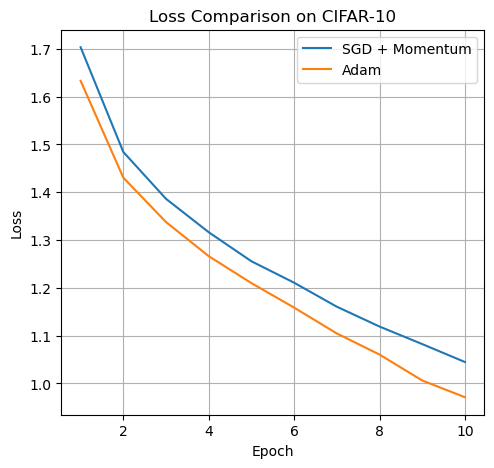

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    range(1, 11),
    losses_sgd,
    label="SGD + Momentum"
)

plt.plot(
    range(1, 11),
    losses_adam,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10")
plt.legend()
plt.grid(True)


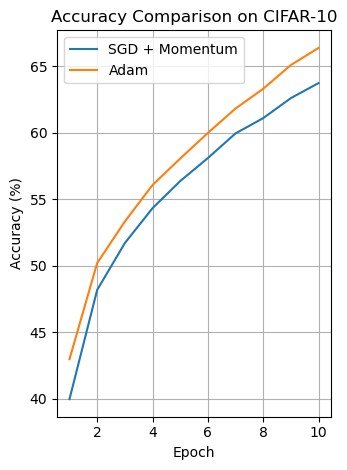

In [10]:
plt.subplot(1, 2, 2)

plt.plot(
    range(1, 11),
    acc_sgd,
    label="SGD + Momentum"
)

plt.plot(
    range(1, 11),
    acc_adam,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()